Read code taken from Kaggle

In [21]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        



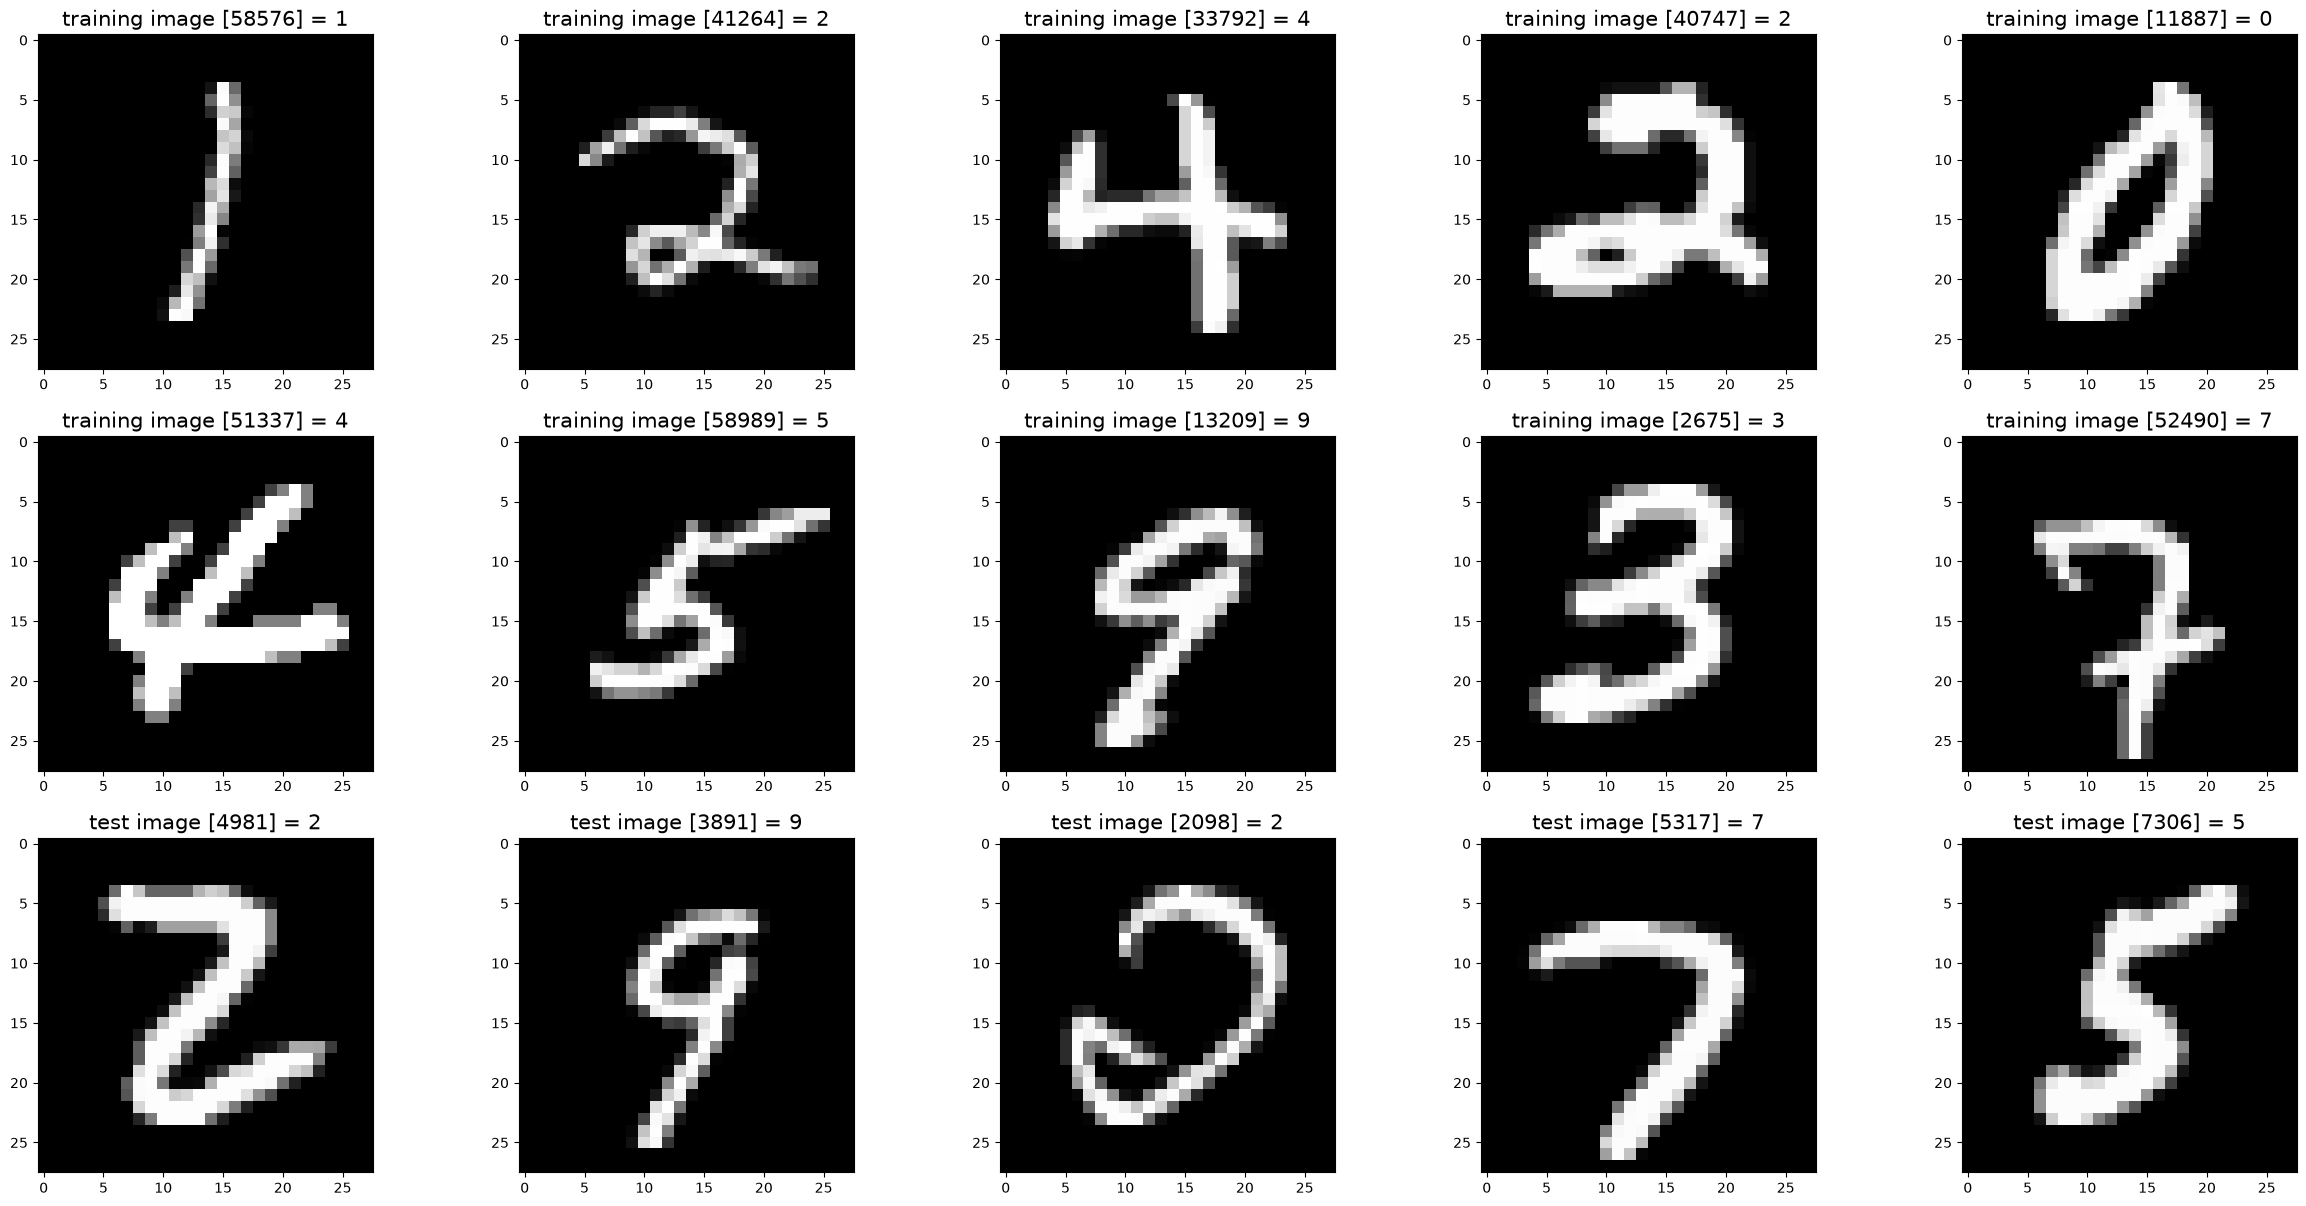

In [22]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt

#
# Set file paths based on added MNIST Datasets
#
input_path = 'mnist/'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [23]:
def flat_from_image(img):
    flat = []
    for row in img:
        flat.extend(row)
    return flat

In [24]:
from nn_tensor import MLP

m = MLP(784, [100, 10], dropout_p=0.2)

In [25]:
# flatten images
loss_vals = []
params = m.parameters()
x_train = np.asarray([flat_from_image(x) for x in x_train],dtype=np.float64) / 255.0
x_test = np.asarray([flat_from_image(x) for x in x_test],dtype=np.float64) / 255.0
y_test = np.asarray(y_test)
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784))

In [26]:
# one hot encoding for y training values 
encode_ys = np.zeros((len(y_train), 10))
for i, label in enumerate(y_train):
    encode_ys[i][label] = 1


In [27]:
def evaluate(m, x, y):
    # give accuracy of m on data x with expected output y
    Z = m(x)
    p = np.argmax(Z.data, axis=1)
    acc = np.sum(np.equal(p, y)) / len(y)
    return acc

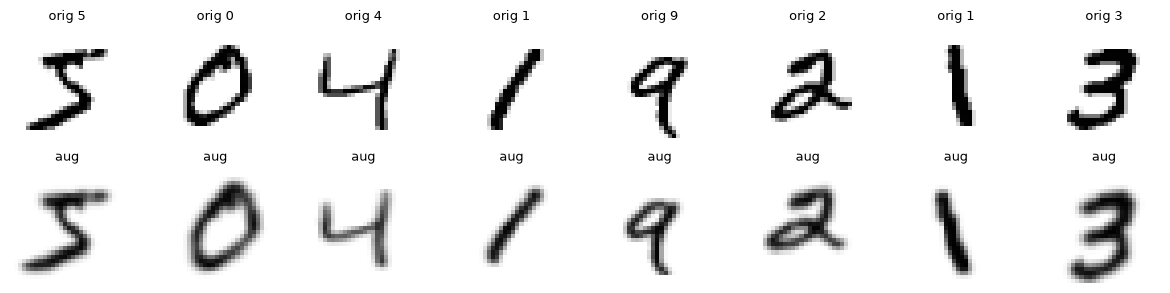

In [28]:
from augment import augment_batch

# show original vs augmented for a handful of digits
n = 8
orig = x_train[:n]                      # (n, 784)
aug  = augment_batch(orig)              # (n, 784)

fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
for i in range(n):
    axes[0, i].imshow(orig[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    axes[0, i].set_title(f'orig {y_train[i]}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(aug[i].reshape(28, 28),  cmap='gray_r', vmin=0, vmax=1)
    axes[1, i].set_title('aug',  fontsize=9)
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os, time
from augment import augment_batch

POOL_PATH = 'mnist_augmented_pool.npz'
K = 4                          # number of augmented copies (final pool = (K+1)x original)

if os.path.exists(POOL_PATH):
    print(f'loading cached pool from {POOL_PATH}')
    data = np.load(POOL_PATH)
    x_pool, y_pool = data['x'], data['y']
    x_pool = x_pool.astype(np.float64)
else:
    print(f'generating {K} augmented copies of x_train...')
    parts_x = [x_train.astype(np.float32)]
    parts_y = [encode_ys.astype(np.float32)]
    for k in range(K):
        t0 = time.time()
        parts_x.append(augment_batch(x_train, shift_px=3, rotate_deg=20, scale_range=
        (0.8, 1.2)).astype(np.float32))
        parts_y.append(encode_ys.astype(np.float32))
        print(f'copy {k+1}/{K} done in {time.time() - t0:.1f}s')
    x_pool = np.concatenate(parts_x)
    y_pool = np.concatenate(parts_y)
    np.savez_compressed(POOL_PATH, x=x_pool, y=y_pool)
    print(f'saved {POOL_PATH} ({os.path.getsize(POOL_PATH) / 1e6:.0f} MB on disk)')

print(f'pool size: {len(x_pool):,} samples ({len(x_pool) / len(x_train):.0f}x original)')

loading cached pool from mnist_augmented_pool.npz
pool size: 300,000 samples (5x original)


In [ ]:

import gc
import time

N_pool = len(x_pool)
batch_size = 128
steps_per_epoch = 60000 // batch_size
num_epochs = 1001
h = 1e-2

start_time = time.time()

# TRAINING LOOP
m.training = True
for epoch in range(num_epochs):

    for step in range(steps_per_epoch):
        idx = np.random.randint(0, N_pool, size=batch_size) # chance of duplicates is negligible and not that important
        xb, yb = x_pool[idx], y_pool[idx]
        
        Z = m(xb)
        loss = Z.softmax_cross_entropy(yb)
        loss_vals.append(loss.data)

        # remember to zero grad!
        for p in params:
            p.grad = np.zeros_like(p.grad)

        loss.backward()
        for p in params:
            p.data -= p.grad * h

    if epoch == 0:
        print(epoch, sum(loss_vals[-50:])/50)
    if epoch % 100 == 0 and epoch > 0:
        # test accuracy on test data
        m.training = False
        acc = evaluate(m, x_test, y_test)
        m.training = True

        print(epoch, f"{sum(loss_vals[-50:])/50:.4f}", f"{(time.time() - start_time) * 100 / epoch:.1f}s/100epochs", f"Mean grad: {np.abs(m.layers[0].W.grad).mean():.6f}", "Test accuracy:", acc)

    if epoch % 20 == 0:
        gc.collect()

0 0.4861344971265757
100 0.5138 41.9s/100epochs Mean grad: 0.000277 Test accuracy: 0.9239
200 0.4968 37.1s/100epochs Mean grad: 0.000370 Test accuracy: 0.9242
300 0.4926 34.6s/100epochs Mean grad: 0.000333 Test accuracy: 0.9238
400 0.4904 35.0s/100epochs Mean grad: 0.000289 Test accuracy: 0.924
500 0.5049 34.7s/100epochs Mean grad: 0.000392 Test accuracy: 0.9237
600 0.5157 34.2s/100epochs Mean grad: 0.000355 Test accuracy: 0.9239
700 0.5204 33.4s/100epochs Mean grad: 0.000304 Test accuracy: 0.9237
800 0.5257 32.1s/100epochs Mean grad: 0.000285 Test accuracy: 0.9237
900 0.5008 31.0s/100epochs Mean grad: 0.000331 Test accuracy: 0.924
1000 0.5087 30.2s/100epochs Mean grad: 0.000302 Test accuracy: 0.9238


In [31]:
np.savez('models/augmented.npz', *[p.data for p in m.parameters()])

In [32]:
np.abs(m.layers[0].W.grad).mean()

np.float64(0.0002363746235227625)

In [33]:
m(x_train[0])

Tensor(data=[ 3.59707733  3.27517577  3.42750355  9.95636353  2.76643337 11.0084108
  1.32824382  3.4476304   7.53313646  5.33924979])

In [34]:
m.training = False
evaluate(m, x_train, y_train)

np.float64(0.9233333333333333)

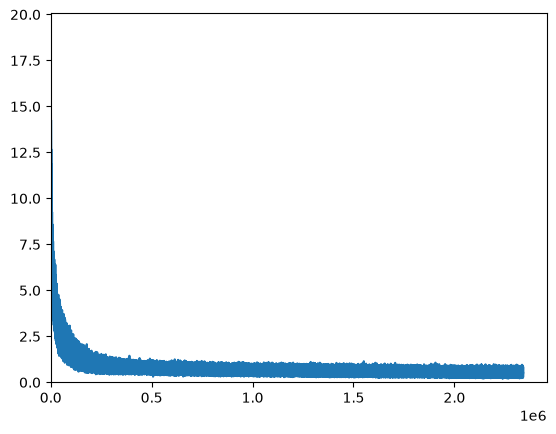

In [35]:
plt.plot(loss_vals)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()